# 4. The Inverse Model 

In this notebook we will learn about the **inverse model** and how it provides the solution to the so-called **inverse problem**.


<div class="alert alert-success">
    <b>Learning Objectives</b>:
     <ul>
      <li>Understanding how to compute the inverse solution with MNE python </li>
      <li>Exploring two different inverse solutions (MNE, LCMV Beamformer) </li>
    </ul>
</div>


![img/phillips2026.jpg](img/phillips2026.jpg)

*Reference: Phillips, A & Vakilna, Yash & Epmoghaddam, D & Banta, A & Mosher, John & Aazhang, Behnaam. (2026). Inferring neural sources from electroencephalography: foundations and frontiers. Journal of Neural Engineering. 23. 10.1088/1741-2552/ae3e16.*

We just computed the forward model describing how signals from neural sources in the brain travel through head tissues and are picked up by the EEG sensors.
But we only have the signal from the sensors, and want to get the source activty. Therefore, the next step is to compute the so called inverse model.
For this we make use of the fact that the approximation of Maxwell's equations shows that the mixing of the neural sources is **linear**.

$$\mathbf{y}(t) \;=\; \mathbf{L}\,\mathbf{x}(t) \;+\; \mathbf{n}(t)$$

| symbol | shape | meaning |
|---|---|---|
| $\mathbf{y}(t)$ | $N \times 1$ | measured sensor data at time $t$ - $N$ channels |
| $\mathbf{L}$ | $N \times M$ | **lead field** (or gain matrix) - $M$ possible neural sources |
| $\mathbf{x}(t)$ | $M \times 1$ | source amplitudes we want to recover |
| $\mathbf{n}(t)$ | $N \times 1$ | noise |


Our goal is now to turn the equation above around and solve it so that we can retreive $\mathbf{x}(t)$!!

Given the 62 EEG measurements, what were the ~20,000 source activities that generated them?

## 4.1 How do we solve the inverse problem?


We know $\mathbf{y}$, we know $\mathbf{L}$, and we want $\mathbf{x}$, but unfortunately we cannot simply invert $\mathbf{L}$, for two independent reasons.

**1. It is underdetermined.** A typical source space has $M \approx 20\,000$ sources, while $N$ is at most a few hundred channels (in our case only 62!), so $M \gg N$. The lead field therefore has a large number of vertices that create the same sensor space data. There is no unique solution!

**2. It is ill-conditioned.** Even inside the row space of $\mathbf{L}$, deep and radially oriented sources project onto the sensors very weakly. Those directions correspond to tiny singular values of $\mathbf{L}$, and naively inverting them multiplies the measurement noise by enormous factors.

The consequence: **the inverse problem has no unique solution, so we must add assumptions.** One assumption is the amount of dipoles we expect. We can either assume a **single dipole**, **a few dipoles**, or many **distributed dipoles**. In this notebook we focus on **distributed dipole** methods.


Every method in this notebook estimates the sources with a single matrix $\mathbf{W}$ of shape $M \times N$, applied to the data:

$$\hat{\mathbf{x}}(t) \;=\; \mathbf{W}\,\mathbf{y}(t)$$

$\mathbf{W}$ is the weight matrix that acts as the *inverse operator*, and row $k$ of $\mathbf{W}$ is the **spatial filter** for source $k$. The methods differ only in how $\mathbf{W}$ is constructed. MNE offers different inverse models and seperates the functions into computing the inverse model (computing the $\mathbf{W}$) and actually applying it to the data (`make_inverse_operator` / `apply_inverse`, `make_lcmv` / `apply_lcmv`).

## 4.2 ... let's compute the inverse solution!
In the following cells we will:
1. Load pre-computed the forward model / leadfiel matrix.
2. Load the epochs and compute the noise and data covariances.
3. Build $\mathbf{W}$ with `make_inverse_operator` and apply minimum norm estimate.
4. *Exercise*: Build $\mathbf{W}$ with `make_lcmv` and apply the beamformer.
5. Save both solutions to disk to plot and compare it later.

In [1]:
# imports
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.minimum_norm import make_inverse_operator, apply_inverse

# data paths
subID = 24
data_path = "data"
subject_path = os.path.join(f"sub-0{subID}", "ses-mecha", "eeg")
base = os.path.join("..", data_path, subject_path, f"sub-0{subID}_ses-mecha_task-NT_")
print(base)

../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_


### 4.2.1 Load the forward model

The forward solution was precomputed and downloaded from the data repository Zenodo in notebook 01. For it's computation we used the BEM head model, the source space and the electrode positions. It contains the lead field $\mathbf{L}$ (see notebook 03) with one scalp
topography per candidate source.

In [2]:
# load forward model
fwd = mne.read_forward_solution(base + "fwd.fif")
print(fwd)

# the lead field itself: (n_channels, n_sources)
print("lead field shape:", fwd["sol"]["data"].shape)
print("source orientation:", fwd["source_ori"])

Reading forward solution from /data/tu_grossmannr/Conferences/CuttingEEG2026/cuttingeeg-2026-sourcerec-tutorial/notebooks/../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_fwd.fif...
    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read EEG forward solution (20484 sources, 62 channels, fixed orientations)
    Source spaces transformed to the forward solution coordinate frame
<Forward | MEG channels: 0 | EEG channels: 62 | Source space: Surface with 20484 vertices | Source orientation: Fixed>
lead field shape: (62, 20484)
source orientation: 1 (FIFFV_MNE_FIXED_ORI)


This forward solution was saved with **fixed orientations**: each source point carries a
single dipole, clamped perpendicular to the cortical surface. So $\mathbf{L}$ is
$N \times M$ and not $N \times 3M$, and the source estimates we get out will be *signed* -
positive means current flowing outward along the surface normal, negative inward.

### 4.2.2 Load the epochs

The same epochs as in notebook 02, plus the two conditions we want to compare.

In [3]:
# load epochs
epochs = mne.read_epochs(base + "epo.fif", preload=False)

evoked = epochs.average()
evoked_perceived = epochs["response_decoded == 'Yes'"].average()
evoked_unperceived = epochs["response_decoded == 'No'"].average()

print(evoked)

Reading /data/tu_grossmannr/Conferences/CuttingEEG2026/cuttingeeg-2026-sourcerec-tutorial/notebooks/../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_epo.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 62)  idle
    Found the data of interest:
        t =    -400.00 ...     300.00 ms
        0 CTF compensation matrices available
Adding metadata with 21 columns
893 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
<Evoked | '15' (average, N=893), -0.4 – 0.3 s, baseline -0.1 – 0 s, 62 ch, ~288 KiB>


### 4.2.3 Noise covariance

The noise covariance $\mathbf{C}$ whitens the sensors: it tells the inverse operator how
noisy each channel is and how the noise is correlated across channels. We estimate it from
the pre-stimulus baseline, where there is no evoked activity.

There are different methods of computing the noise covariance.
`method=["shrunk", "empirical"]` lets MNE fit both estimators and pick the one with the best
cross-validated log-likelihood. `rank="info"` makes it respect the rank deficiency caused by
the average reference (62 channels, rank 61).

In [4]:
# compute noise covariance from the baseline
noise_cov = mne.compute_covariance(epochs, tmax=0.0, method=["shrunk", "empirical"],
                                   rank="info")
print(noise_cov)
print("selected method:", noise_cov["method"])

Loading data for 893 events and 351 original time points ...
    Created an SSP operator (subspace dimension = 1)
    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 62 -> 61
Estimating covariance using SHRUNK
Done.
Estimating covariance using EMPIRICAL
Done.
Using cross-validation to select the best estimator.
Number of samples used : 179493
log-likelihood on unseen data (descending order):
   shrunk: -95.619
   empirical: -95.810
selecting best estimator: shrunk
[done]
<Covariance | kind : full, shape : (62, 62), range : [-1.6e-11, +3.4e-11], n_samples : 179492>
selected method: shrunk


Computing rank from covariance with rank=None
    Using tolerance 5.6e-14 (2.2e-16 eps * 62 dim * 4  max singular value)
    Estimated rank (eeg): 61
    EEG: rank 61 computed from 62 data channels with 0 projectors


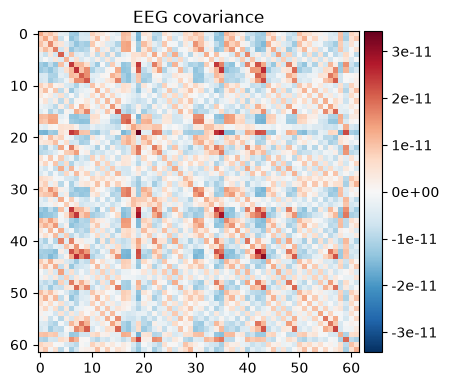

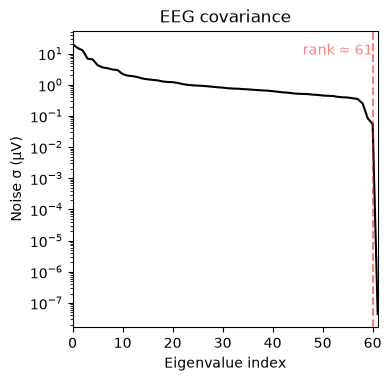

In [5]:
# the covariance matrix and its eigenvalue spectrum
mne.viz.plot_cov(noise_cov, epochs.info)
plt.show()

### 4.2.4 Build the Minimum Norm inverse operator

`make_inverse_operator` assembles $\mathbf{W}$ from the lead field, the noise covariance and
the source prior $\mathbf{R}$ which we use to formulate further assumptions (for example about the possible depth of the dipole).

Two arguments are forced by our forward solution:

- `loose=0.` - the forward is already fixed-orientation, so the inverse must be too. Any
  other value raises *"Forward operator has fixed orientation and can only be used to make a
  fixed-orientation inverse operator"*.
- `depth=None` - depth weighting reshapes $\mathbf{R}$ using the free-orientation lead
  fields, which are no longer in the file. With a fixed forward, MNE refuses `depth`.
  With `depth=None`, the solution is biased towards superficial sources.

In [6]:
# compute inverse operator
inverse_operator = make_inverse_operator(evoked.info, fwd, noise_cov,
                                         loose=0.0, depth=None)
print(inverse_operator)

Computing inverse operator with 62 channels.
    62 out of 62 channels remain after picking
Selected 62 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 1)
Computing rank from covariance with rank=None
    Using tolerance 5.6e-14 (2.2e-16 eps * 62 dim * 4  max singular value)
    Estimated rank (eeg): 61
    EEG: rank 61 computed from 62 data channels with 1 projector
    Setting small EEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing SVD of whitened and weighted lead field matrix.
    largest singular value = 4.69227
    scaling factor to adjust the trace = 2.04337e+21 (nchan = 62 nzero = 1)
<InverseOperator | MEG channels: 0 | EEG channels: 62 | Source space: surface with 20484 sources | Source orientation: Fixed>


### 4.2.5 Apply it to the data

$\hat{\mathbf{x}}(t) = \mathbf{W}\,\mathbf{y}(t)$ - one matrix multiplication per time
point. The regularisation $\lambda^2$ is set from an assumed SNR: `lambda2 = 1 / snr**2`.
A larger $\lambda^2$ trusts the prior more (smoother, weaker estimates), a smaller one
trusts the data more (noisier estimates).

`method="MNE"` gives the plain minimum-norm estimate in ampere-metres. `"dSPM"` and
`"sLORETA"` would return the same map noise-normalised.

In [7]:
# apply inverse method
snr = 3.0
lambda2 = 1.0 / snr ** 2
method = "MNE"

stc = apply_inverse(evoked, inverse_operator, lambda2, method=method, pick_ori=None)
stc_perceived = apply_inverse(evoked_perceived, inverse_operator, lambda2, method=method)
stc_unperceived = apply_inverse(evoked_unperceived, inverse_operator, lambda2, method=method)

# the contrast: source estimates can be subtracted like arrays
stc_difference = stc_perceived - stc_unperceived

print(stc)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 893
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 61 (1 small eigenvalues omitted)
Applying inverse operator to "15"...
    Picked 62 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  76.4% variance
[done]
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 488
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 61 (1 small eigenvalues omitted)
Applying inverse operator to "15"...
    Picked 62 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  76.9% variance
[done]


In [8]:
# where and when is the estimate largest?
vertex, latency = stc.get_peak(tmin=0.05, tmax=0.3)
print(f"peak at vertex {vertex}, {latency * 1000:.0f} ms")

peak at vertex 14647, 204 ms


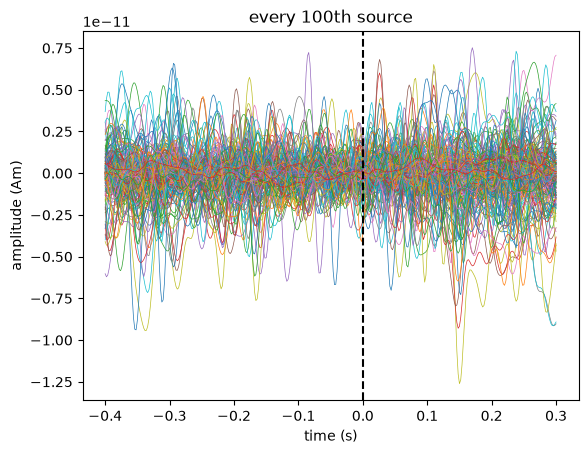

In [9]:
# a first look: the source time courses of all vertices
plt.plot(stc.times, stc.data[::100, :].T, linewidth=0.5)
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("amplitude (Am)")
plt.title("every 100th source")
plt.show()

### 4.2.6 Save the source estimates

`stc.save()` writes one file per hemisphere (`...-lh.stc` and `...-rh.stc`). These are still
in the **individual** source space of this participant - notebook 05 morphs them to
*fsaverage* for plotting.

In [10]:
for name, estimate in [("all", stc),
                       ("perceived", stc_perceived),
                       ("unperceived", stc_unperceived),
                       ("difference", stc_difference)]:
    fname = base + f"MNE-{name}"
    estimate.save(fname, overwrite=True)
    print("saved", fname + "-lh.stc", "/", fname + "-rh.stc")

Writing STC to disk...
Overwriting existing file.
Overwriting existing file.
[done]
saved ../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_MNE-all-lh.stc / ../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_MNE-all-rh.stc
Writing STC to disk...
Overwriting existing file.
Overwriting existing file.
[done]
saved ../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_MNE-perceived-lh.stc / ../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_MNE-perceived-rh.stc
Writing STC to disk...
Overwriting existing file.
Overwriting existing file.
[done]
saved ../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_MNE-unperceived-lh.stc / ../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_MNE-unperceived-rh.stc
Writing STC to disk...
Overwriting existing file.
Overwriting existing file.
[done]
saved ../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_MNE-difference-lh.stc / ../data/sub-024/ses-mecha/eeg/sub-024_ses-mecha_task-NT_MNE-difference-rh.stc


<div class="alert alert-warning">
    <b>Exercise</b>:
    Do the same inverse computation just using the LCMV beamformer. For that you can look up in the MNE documentation. Tipp: for the LCMV beamformer you also need to compute the data covariance matrix.
</div>

In [11]:
# your code geos here ...